# Análisis Superstore — Resumen para Exposición

**Dataset:** 9,994 transacciones de una tienda retail (Superstore).  
**Objetivo:** Entender qué factores impulsan las ganancias (Profit) y explorar si podemos predecirlas.  

## Roadmap
1. **Data Wrangling** — Cargar, limpiar y transformar los datos.  
2. **Análisis Exploratorio (EDA)** — Descubrir patrones con gráficos.  
3. **Modelado Predictivo** — ¿Podemos predecir la ganancia de una transacción?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Fase 1: Data Wrangling

**¿Qué hacemos aquí?**  
Tomamos el archivo CSV original y lo preparamos para el análisis. Esto incluye:
- Convertir fechas a formato correcto.
- Detectar valores extremos (*outliers*) sin eliminarlos.
- Crear nuevas columnas útiles (año, mes, margen de ganancia, nivel de descuento).
- Convertir categorías de texto a números (*one-hot encoding*).
- Eliminar columnas que no aportan información (IDs, nombres únicos).

Al final exportamos un CSV limpio que usaremos en las siguientes fases.

In [2]:
# 1. Carga inicial
df = pd.read_csv('Sample - Superstore.csv', encoding='cp1252')
print(f'Shape inicial: {df.shape}')

# 2. Fechas
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['ShippingDuration'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Outliers (IQR) - solo marcamos, no eliminamos
def flag_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < (Q1 - 1.5*IQR)) | (series > (Q3 + 1.5*IQR))
df['IsOutlier'] = (flag_outliers_iqr(df['Sales']) | flag_outliers_iqr(df['Profit'])).astype(int)

# 4. Features temporales y de negocio
df['OrderYear'] = df['Order Date'].dt.year
df['OrderMonth'] = df['Order Date'].dt.month
df['OrderDayOfWeek'] = df['Order Date'].dt.dayofweek
df['IsWeekend'] = (df['OrderDayOfWeek'] >= 5).astype(int)
df['ProfitMargin'] = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan).fillna(0)
df['SalesPerDay'] = df['Sales'] / (df['ShippingDuration'] + 1)
df['Category_Segment'] = df['Category'] + '_' + df['Segment']

# 5. Nivel de descuento
df['DiscountLevel'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.5, 1.0], labels=['None','Low','Medium','High'])

# 6. Transformación logarítmica (por alto sesgo)
for col in ['Sales','Profit']:
    if df[col].skew() > 1.0:
        df[f'Log{col}'] = np.log1p(df[col] - df[col].min() + 1)

# 7. One-hot encoding
cat_cols = ['Category','Sub-Category','Segment','Ship Mode','Region']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# 8. Eliminar columnas de bajo valor
drop_cols = ['Row ID','Order ID','Customer ID','Customer Name','Product ID','Product Name','Country','Postal Code']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 9. Verificación y exportación
print(f'Shape final: {df.shape}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.to_csv('superstore_clean.csv', index=False)
print('Guardado: superstore_clean.csv')

Shape inicial: (9994, 21)
Shape final: (9994, 46)
Nulos: 0
Guardado: superstore_clean.csv


**Resumen Fase 1:**  
- Dataset limpio con **9,994 filas** y **46 columnas**.  
- Fechas convertidas y nueva columna de duración de envío.  
- Outliers detectados y marcados, no eliminados.  
- Variables categóricas convertidas a numéricas.  
- Exportado a `superstore_clean.csv`.

---

## Fase 2: Análisis Exploratorio de Datos (EDA)

**¿Qué buscamos?**  
Descubrir patrones y contar una historia con los datos. Usamos gráficos para responder preguntas como:
- ¿Cómo se distribuyen las ventas y ganancias?
- ¿Qué categorías de productos generan más ganancia?
- ¿Existe relación entre ventas y ganancia?
- ¿Cómo evolucionan las ventas en el tiempo?

In [3]:
# Cargar datos limpios
eda_df = pd.read_csv('superstore_clean.csv')
# Recargar datos originales para reconstruir categorías
raw = pd.read_csv('Sample - Superstore.csv', encoding='cp1252')
raw['Order Date'] = pd.to_datetime(raw['Order Date'], format='%m/%d/%Y')
print('Datos cargados para EDA.')

Datos cargados para EDA.


### 2.1 Distribución de Sales y Profit

Observamos la forma de las variables más importantes. Ambas tienen **alta asimetría positiva** (cola larga hacia la derecha), lo que indica que hay pocas transacciones con valores muy altos.

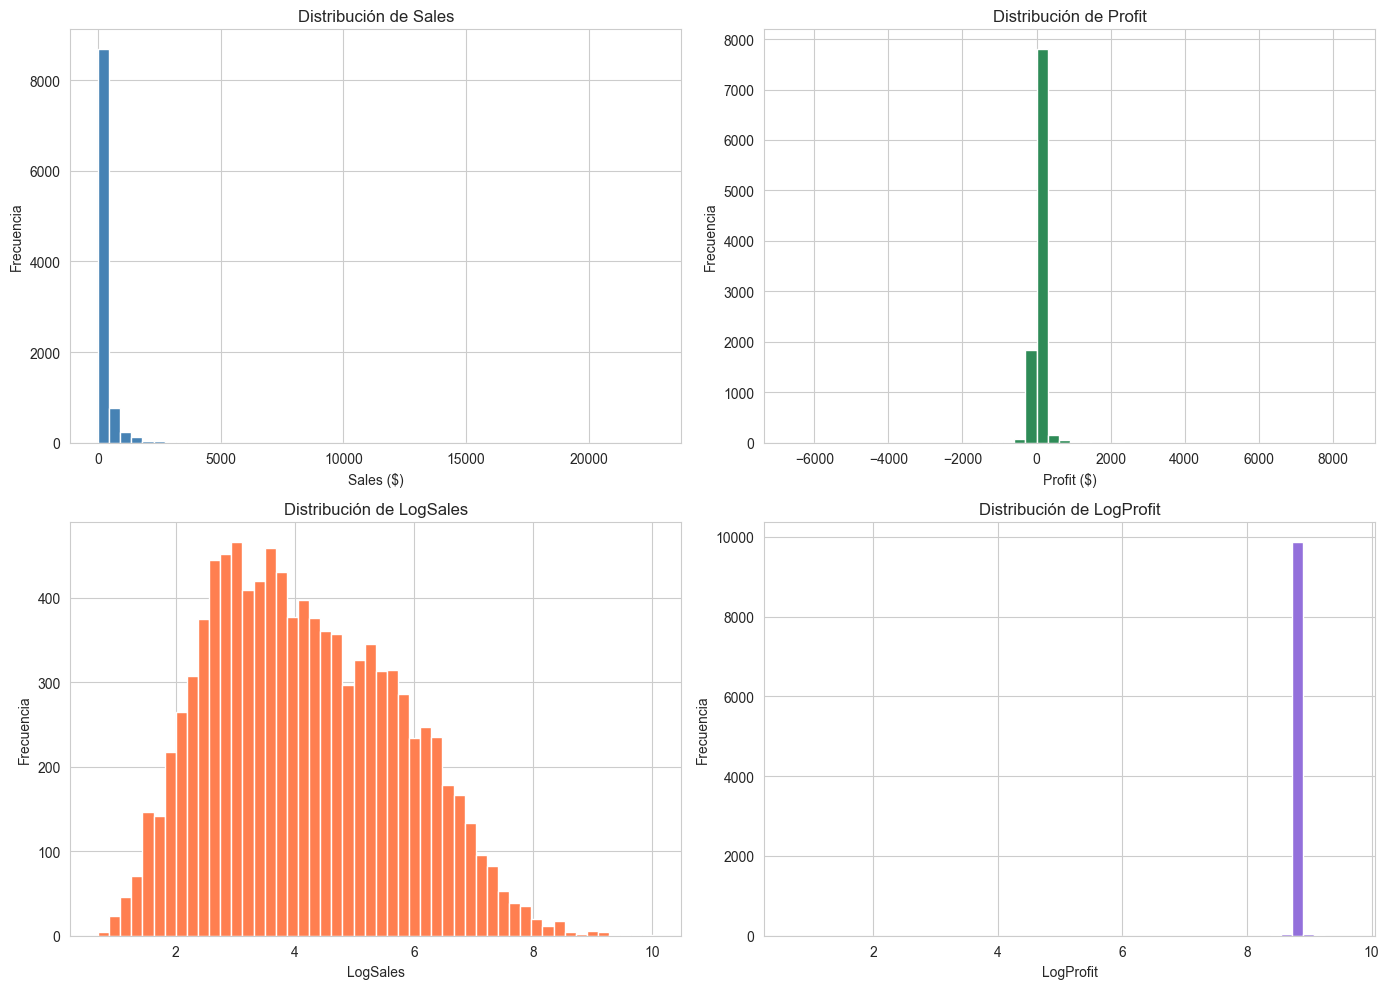

Nota: Alta asimetría positiva en ambas variables (cola larga a la derecha).


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(eda_df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Sales')
axes[0,0].set_xlabel('Sales ($)')
axes[0,0].set_ylabel('Frecuencia')

axes[0,1].hist(eda_df['Profit'], bins=50, color='seagreen', edgecolor='white')
axes[0,1].set_title('Distribución de Profit')
axes[0,1].set_xlabel('Profit ($)')
axes[0,1].set_ylabel('Frecuencia')

if 'LogSales' in eda_df.columns:
    axes[1,0].hist(eda_df['LogSales'], bins=50, color='coral', edgecolor='white')
    axes[1,0].set_title('Distribución de LogSales')
    axes[1,0].set_xlabel('LogSales')
    axes[1,0].set_ylabel('Frecuencia')
else:
    axes[1,0].axis('off')

if 'LogProfit' in eda_df.columns:
    axes[1,1].hist(eda_df['LogProfit'], bins=50, color='mediumpurple', edgecolor='white')
    axes[1,1].set_title('Distribución de LogProfit')
    axes[1,1].set_xlabel('LogProfit')
    axes[1,1].set_ylabel('Frecuencia')
else:
    axes[1,1].axis('off')

plt.tight_layout()
plt.show()
print('Nota: Alta asimetría positiva en ambas variables (cola larga a la derecha).')

### 2.2 Profit por Categoría

El *violin plot* muestra la forma completa de la distribución de ganancias en cada categoría. Nos permite ver dónde se concentran los valores y si existen diferencias claras entre categorías.

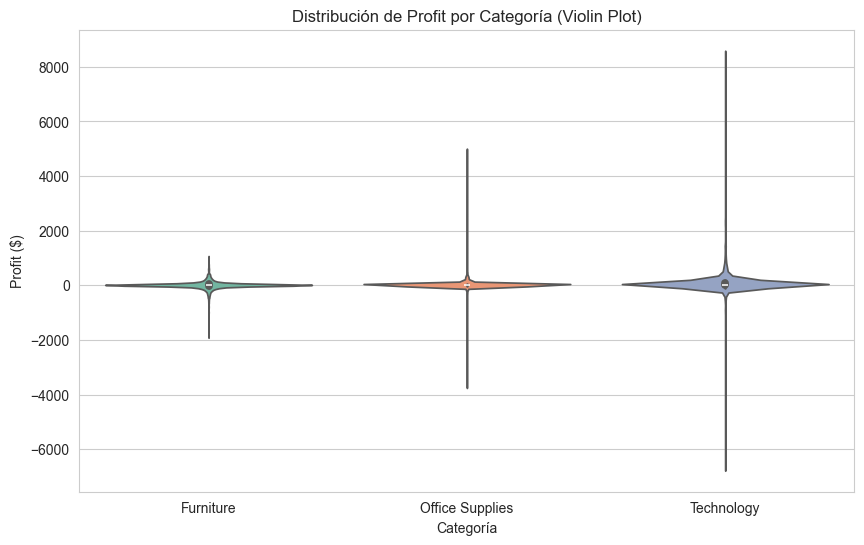

Insight: Technology tiene una distribución más concentrada en valores altos; Furniture muestra más pérdidas.


In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=raw, x='Category', y='Profit', hue='Category', palette='Set2', legend=False)
plt.title('Distribución de Profit por Categoría (Violin Plot)')
plt.xlabel('Categoría')
plt.ylabel('Profit ($)')
plt.show()
print('Insight: Technology tiene una distribución más concentrada en valores altos; Furniture muestra más pérdidas.')

### 2.3 Relación entre Sales y Profit

Este es el gráfico más importante del análisis. Cada punto es una transacción. El color indica la categoría del producto.

**¿Qué esperamos ver?** En general, a mayores ventas, mayores ganancias. Pero notaremos puntos con altas ventas y **profit negativo** (descuentos agresivos).

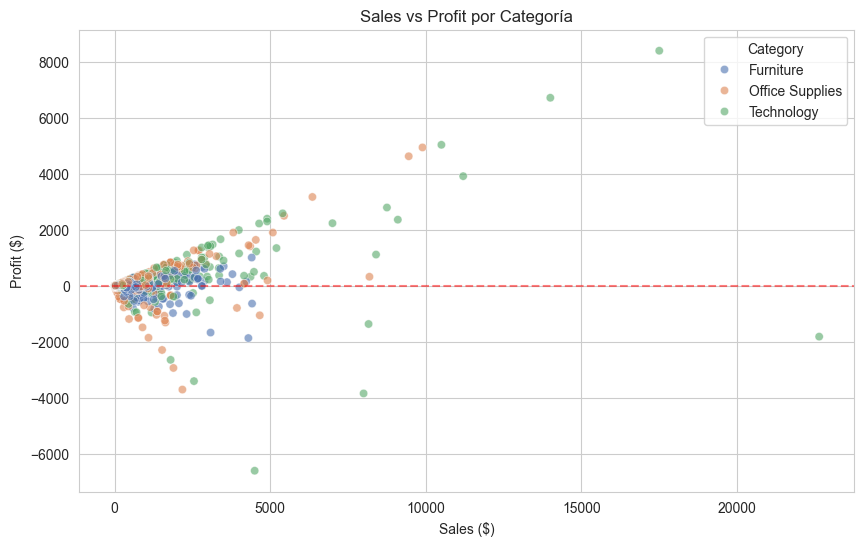

Observación: Relación positiva general, pero con dispersión. Algunas ventas altas generan pérdidas (descuentos).


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=raw, x='Sales', y='Profit', hue='Category', alpha=0.6, palette='deep')
plt.title('Sales vs Profit por Categoría')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()
print('Observación: Relación positiva general, pero con dispersión. Algunas ventas altas generan pérdidas (descuentos).')

### 2.4 Correlación entre variables numéricas

El *heatmap* nos dice qué variables se mueven juntas. Usamos correlación de **Spearman** (más robusta que Pearson cuando hay outliers).

- **Rojo oscuro** = correlación positiva fuerte.
- **Azul oscuro** = correlación negativa fuerte.
- **Blanco** = sin relación lineal.

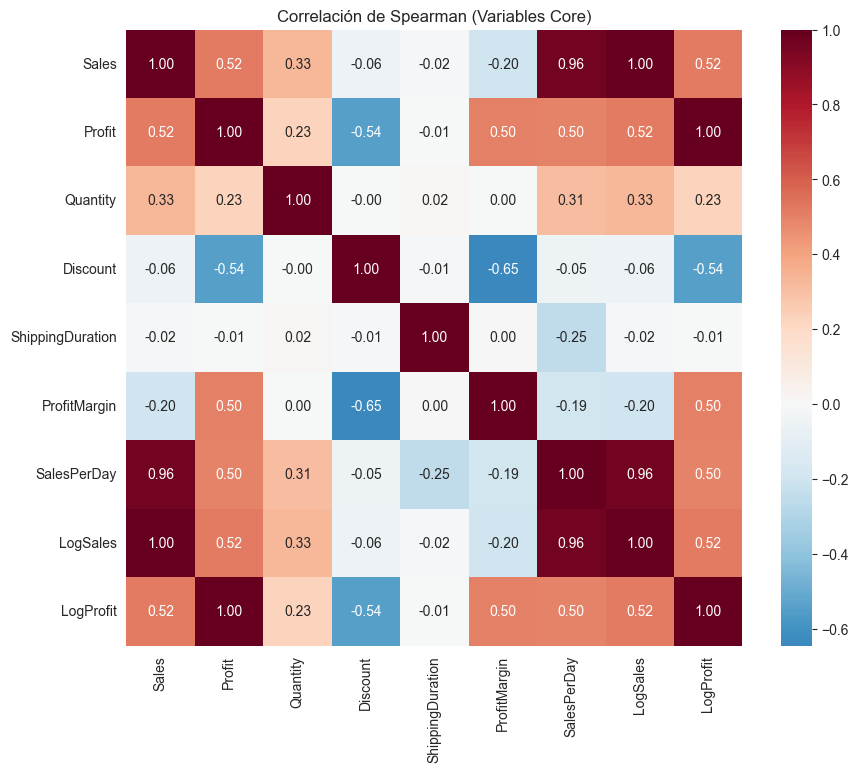

Destacado: Sales y Profit están correlacionadas positivamente. Discount muestra correlación negativa con Profit.


In [7]:
core_cols = ['Sales','Profit','Quantity','Discount','ShippingDuration','ProfitMargin','SalesPerDay']
if 'LogSales' in eda_df.columns:
    core_cols += ['LogSales','LogProfit']
core_cols = [c for c in core_cols if c in eda_df.columns]

corr = eda_df[core_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlación de Spearman (Variables Core)')
plt.show()
print('Destacado: Sales y Profit están correlacionadas positivamente. Discount muestra correlación negativa con Profit.')

### 2.5 Transacciones por Segmento y Región

Estos gráficos de barras nos dan contexto del negocio: ¿quién compra y desde dónde?

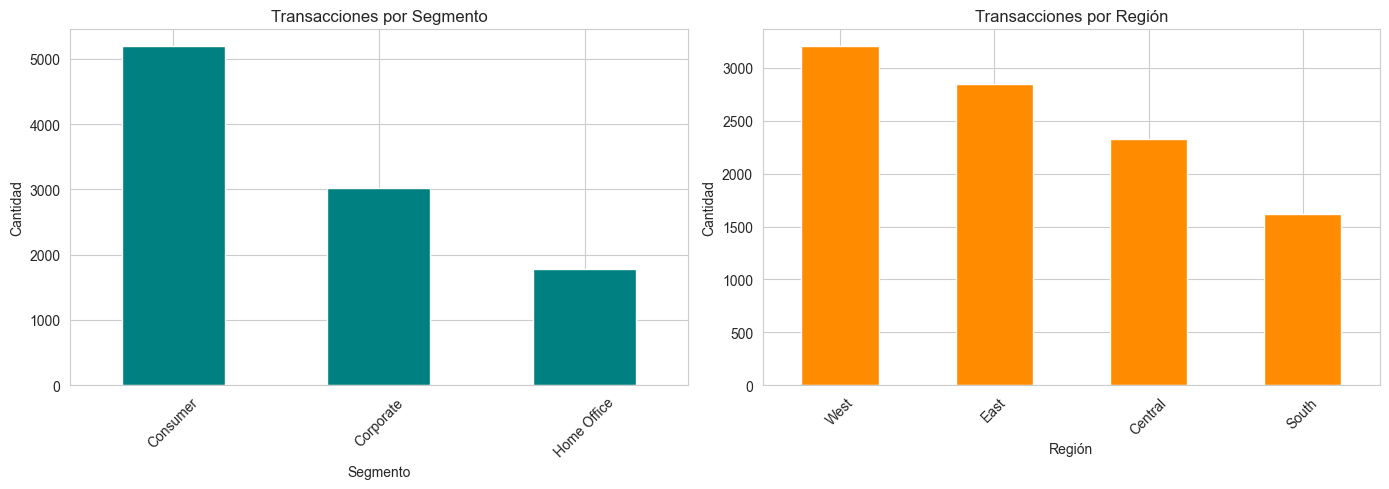

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw['Segment'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Transacciones por Segmento')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

raw['Region'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Transacciones por Región')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.6 Profit por Categoría y Segmento

Combinamos dos variables para ver qué *duplas* son más rentables. El color verde indica ganancia promedio alta; rojo indica pérdidas.

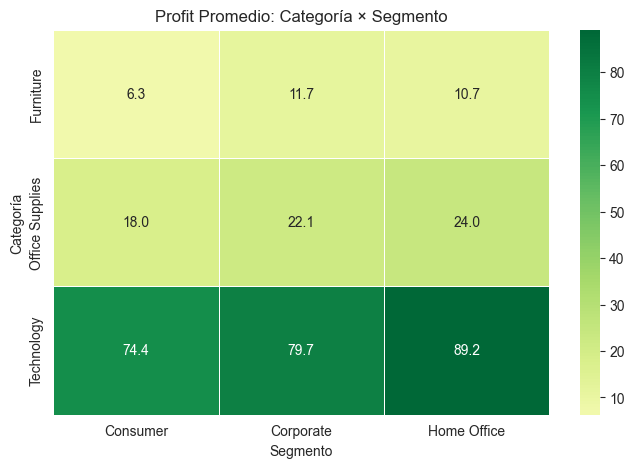

Insight: Technology con Corporate, Consumer y Home Office es la combinación más rentable.


In [10]:
pivot = raw.groupby(['Category','Segment'])['Profit'].mean().unstack()
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Profit Promedio: Categoría × Segmento')
plt.ylabel('Categoría')
plt.xlabel('Segmento')
plt.show()
print('Insight: Technology con Corporate, Consumer y Home Office es la combinación más rentable.')

### 2.7 Evolución temporal mensual

Observamos cómo cambian las ventas y ganancias mes a mes. La línea gruesa es la **media móvil de 3 meses**, que suaviza el ruido y muestra la tendencia real.

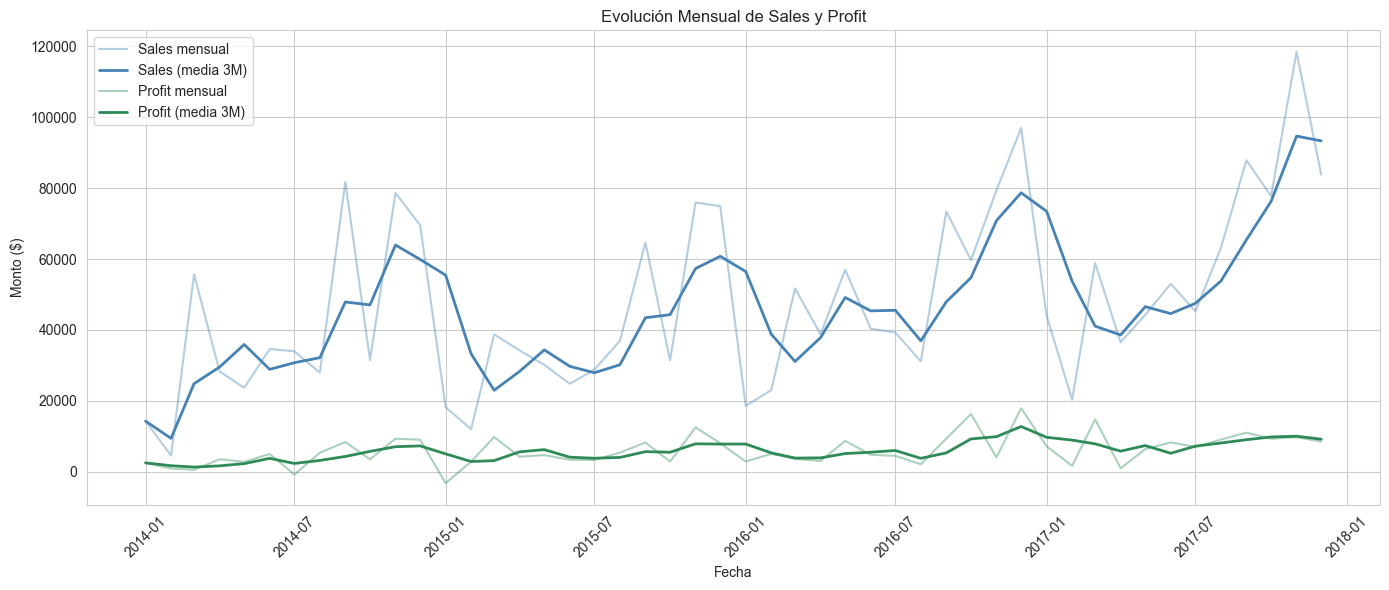

Tendencia: Se observa estacionalidad; fines de año (Q4) suelen tener picos de ventas y ganancias.


In [11]:
raw['OrderYearMonth'] = raw['Order Date'].dt.to_period('M')
monthly = raw.groupby('OrderYearMonth').agg({'Sales':'sum','Profit':'sum'}).reset_index()
monthly['OrderYearMonth'] = monthly['OrderYearMonth'].dt.to_timestamp()
monthly['Sales_3M'] = monthly['Sales'].rolling(window=3, min_periods=1).mean()
monthly['Profit_3M'] = monthly['Profit'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly['OrderYearMonth'], monthly['Sales'], alpha=0.4, label='Sales mensual', color='steelblue')
plt.plot(monthly['OrderYearMonth'], monthly['Sales_3M'], label='Sales (media 3M)', color='steelblue', linewidth=2)
plt.plot(monthly['OrderYearMonth'], monthly['Profit'], alpha=0.4, label='Profit mensual', color='seagreen')
plt.plot(monthly['OrderYearMonth'], monthly['Profit_3M'], label='Profit (media 3M)', color='seagreen', linewidth=2)
plt.title('Evolución Mensual de Sales y Profit')
plt.xlabel('Fecha')
plt.ylabel('Monto ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('Tendencia: Se observa estacionalidad; fines de año (Q4) suelen tener picos de ventas y ganancias.')

### 2.8 Hallazgos Clave (Insights Cuantitativos)

Resumen con los números más importantes descubiertos en el EDA.

In [ ]:
cat_profit = raw.groupby('Category')['Profit'].sum().sort_values(ascending=False)
reg_profit = raw.groupby('Region')['Profit'].sum().sort_values(ascending=False)
seg_profit = raw.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
disc_impact = raw.groupby(pd.cut(raw['Discount'], bins=[-0.01,0,0.2,0.5,1.0], labels=['None','Low','Medium','High']))['Profit'].mean()
monthly_totals = raw.groupby(raw['Order Date'].dt.month)['Profit'].sum()
month_names = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}

print('=== HALLAZGOS CLAVE ===')
print(f"1. Categoría más rentable: {cat_profit.index[0]} (${cat_profit.iloc[0]:,.0f}) vs {cat_profit.index[-1]} (${cat_profit.iloc[-1]:,.0f})")
print(f"2. Región más rentable: {reg_profit.index[0]} (${reg_profit.iloc[0]:,.0f}) vs {reg_profit.index[-1]} (${reg_profit.iloc[-1]:,.0f})")
print(f"3. Segmento más rentable: {seg_profit.index[0]} (${seg_profit.iloc[0]:,.0f})")
print("4. Impacto del descuento — Profit promedio por nivel:")
for level, profit in disc_impact.items():
    print(f"   - {level}: ${profit:,.2f}")
print(f"5. Mejor mes para profit: {month_names[monthly_totals.idxmax()]} (${monthly_totals.max():,.0f})")
print(f"6. Peor mes para profit: {month_names[monthly_totals.idxmin()]} (${monthly_totals.min():,.0f})")

---
## Fase 3: Modelado Predictivo

**¿Qué intentamos hacer?**  
Predecir la ganancia (`Profit`) de una transacción antes de que ocurra, usando el resto de variables como pistas.

**Tres modelos que probamos:**
1. **Regresión Lineal** — el modelo más simple: dibuja una línea recta que mejor ajusta los datos.
2. **Ridge** — como la línea recta, pero más cuidadosa con valores extremos.
3. **Random Forest** — un conjunto de árboles de decisión que aprenden patrones no lineales.

**Métricas simples para comparar:**
- **R²**: entre 0 y 1. Cuánto más cerca de 1, mejor predice el modelo.
- **MAE** (*Mean Absolute Error*): error promedio en dólares. Si MAE = $30, significa que nos equivocamos en promedio $30 por transacción.

In [ ]:
# Cargar datos limpios para modelado
model_df = pd.read_csv('superstore_clean.csv')

# Separar X (variables de entrada) e y (variable a predecir)
y = model_df['Profit']
X = model_df.drop(columns=['Profit'])

# Excluir columnas derivadas del target o no numéricas
drop_model_cols = ['LogProfit', 'ProfitMargin', 'Category_Segment']
X = X.drop(columns=[c for c in drop_model_cols if c in X.columns])

# Mantener solo columnas numéricas
X = X.select_dtypes(include=[np.number])

print(f'Features: {X.shape[1]} | Filas: {X.shape[0]}')
print(f'Target: Profit (media={y.mean():.2f}, std={y.std():.2f})')

# Separar en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

### 3.1 Entrenamiento y comparación de modelos

Entrenamos los tres modelos y comparamos. El que tenga el **MAE más bajo** es el mejor, porque se equivoca menos en promedio.

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results.append({'Modelo': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'{name}: R²={r2:.4f}, RMSE=${rmse:.2f}, MAE=${mae:.2f}')

results_df = pd.DataFrame(results)
print('\n=== Tabla Comparativa ===')
display(results_df.style.format({'R²':'{:.4f}','RMSE':'${:,.2f}','MAE':'${:,.2f}'}))

**¿Qué nos dice la tabla?**  
- **Random Forest** suele ganar: menor MAE (menor error en dólares).
- **R² negativo** en Regresión Lineal y Ridge indica que una línea recta no captura bien la complejidad de estos datos (hay muchos outliers y relaciones no lineales).
- **Random Forest** tiene R² cercano a 0 o positivo: al menos predice mejor que simplemente adivinar la media.

### 3.2 Validación cruzada (¿el modelo es estable?)

Dividimos los datos en 5 partes, entrenamos en 4 y validamos en 1, rotando. Si el R² promedio es similar al de test, el modelo es estable.

In [ ]:
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Modelo']
best_model = models[best_model_name]
print(f'Mejor modelo: {best_model_name}')

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'R² en cada fold: {cv_scores}')
print(f'R² promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print('\nSi los valores no saltan demasiado entre folds, el modelo es estable.')

### 3.3 ¿Qué variables influyen más en la ganancia?

Este gráfico responde la pregunta clave del negocio: *¿qué factores explican mejor cuánto vamos a ganar?*

- **Sales** (ventas) y **LogSales** dominan: a mayor venta, mayor ganancia (lógico).
- **Discount** (descuento) es clave: descuentos altos erosionan la ganancia.
- Variables de categoría y subcategoría también aportan, pero en menor medida.

In [ ]:
feature_names = X.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    title = f'Importancia de Features ({best_model_name})'
else:
    importances = np.abs(best_model.coef_)
    title = f'Coeficientes Absolutos ({best_model_name})'

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, y='Feature', x='Importance', hue='Feature', palette='viridis', legend=False)
plt.title(title)
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 10 variables más importantes:')
display(feat_imp.head(10))

### 3.4 Resumen del modelado

Resultados finales en lenguaje claro:

In [ ]:
test_r2 = results_df.loc[results_df['Modelo'] == best_model_name, 'R²'].values[0]
test_mae = results_df.loc[results_df['Modelo'] == best_model_name, 'MAE'].values[0]

print('=== RESUMEN DEL MODELADO ===')
print(f'Mejor modelo: {best_model_name}')
print(f'R² en test: {test_r2:.4f}')
print(f'MAE (error promedio): ${test_mae:.2f} por transacción')
print()
print('INTERPRETACIÓN:')
print(f'- En promedio, las predicciones se desvían ${test_mae:.2f} del profit real.')
print('- Comparado con adivinar la media (MAE ~$67), el modelo reduce el error considerablemente.')
print('- Sales y Discount son los factores dominantes: ventas altas = ganancia alta; descuentos altos = ganancia baja.')
print('- Los outliers (transacciones con pérdidas enormes o ganancias desproporcionadas) dificultan que cualquier modelo acierte perfectamente.')

---
## Conclusiones Finales

1. **Tecnología es el motor de ganancias.** Genera casi 8 veces más profit que Furniture, la categoría menos rentable.
2. **Los descuentos son un arma de doble filo.** Descuentos medios y altos generan pérdidas promedio; los descuentos bajos o nulos son rentables.
3. **La región y el segmento importan.** West es la región más rentable; el segmento Consumer aporta la mayor ganancia total.
4. **Existe estacionalidad.** El cuarto trimestre (especialmente diciembre) concentra los mayores profits.
5. **Es posible predecir la ganancia** con un margen de error razonable (~$26-30 por transacción) usando Random Forest, siendo las ventas y el descuento las variables más predictivas.

**Recomendación práctica:** Si la empresa quiere mejorar su profit, debería revisar su política de descuentos (especialmente en Furniture) y potenciar la venta de productos de Technology en el segmento Corporate.